# Notebook 03 — AlphaMissense Variant Pathogenicity

**Goal:** Download AlphaMissense scores for every possible FHL1 mutation. Benchmark against ClinVar clinical variants. Overlay on pLDDT confidence profile.

**Hypothesis:** Pathogenic mutations cluster in structured LIM domains (high pLDDT). Disordered tail tolerates mutations.

In [2]:
import subprocess
subprocess.run(["pip", "install", "tqdm"])

CompletedProcess(args=['pip', 'install', 'tqdm'], returncode=0)

In [4]:
import requests
import pandas as pd
import gzip
import os
from tqdm import tqdm

save_path = "../data/processed/FHL1_alphamissense.csv"
gz_path = "../data/raw/alphamissense.tsv.gz"

if os.path.exists(save_path):
    df = pd.read_csv(save_path)
    print(f"Loaded from disk — {len(df)} variants")

else:
    # step 1: download .gz file to disk
    if not os.path.exists(gz_path):
        url = "https://zenodo.org/records/8208688/files/AlphaMissense_aa_substitutions.tsv.gz"
        print("Downloading...")
        response = requests.get(url, stream=True, timeout=300)
        total = int(response.headers.get("content-length", 0))

        with open(gz_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in response.iter_content(chunk_size=1024*1024):
                f.write(chunk)
                bar.update(len(chunk))
        print("Download complete")

    # step 2: read line by line — never loads full file into memory
    print("Filtering for FHL1...")
    rows = []
    with gzip.open(gz_path, "rt") as f:
        for line in tqdm(f, desc="Scanning"):
            if line.startswith("#"):
                continue
            if "Q13642" in line:
                rows.append(line.strip().split("\t"))

    columns = ["uniprot_id", "variant", "am_pathogenicity", "am_class"]
    df = pd.DataFrame(rows, columns=columns)
    df["am_pathogenicity"] = df["am_pathogenicity"].astype(float)
    df["ref_aa"] = df["variant"].str[0]
    df["position"] = df["variant"].str[1:-1].astype(int)
    df["alt_aa"] = df["variant"].str[-1]

    df.to_csv(save_path, index=False)
    print(f"Done — {len(df)} variants saved")

print(df.head())

Downloading...


100%|██████████| 1.21G/1.21G [24:27<00:00, 823kB/s]  


Download complete
Filtering for FHL1...


Scanning: 216175355it [01:07, 3217900.37it/s]

Done — 6137 variants saved
  uniprot_id variant  am_pathogenicity    am_class ref_aa  position alt_aa
0     Q13642     M1A            0.6602  pathogenic      M         1      A
1     Q13642     M1C            0.6435  pathogenic      M         1      C
2     Q13642     M1D            0.9648  pathogenic      M         1      D
3     Q13642     M1E            0.8716  pathogenic      M         1      E
4     Q13642     M1F            0.5198   ambiguous      M         1      F


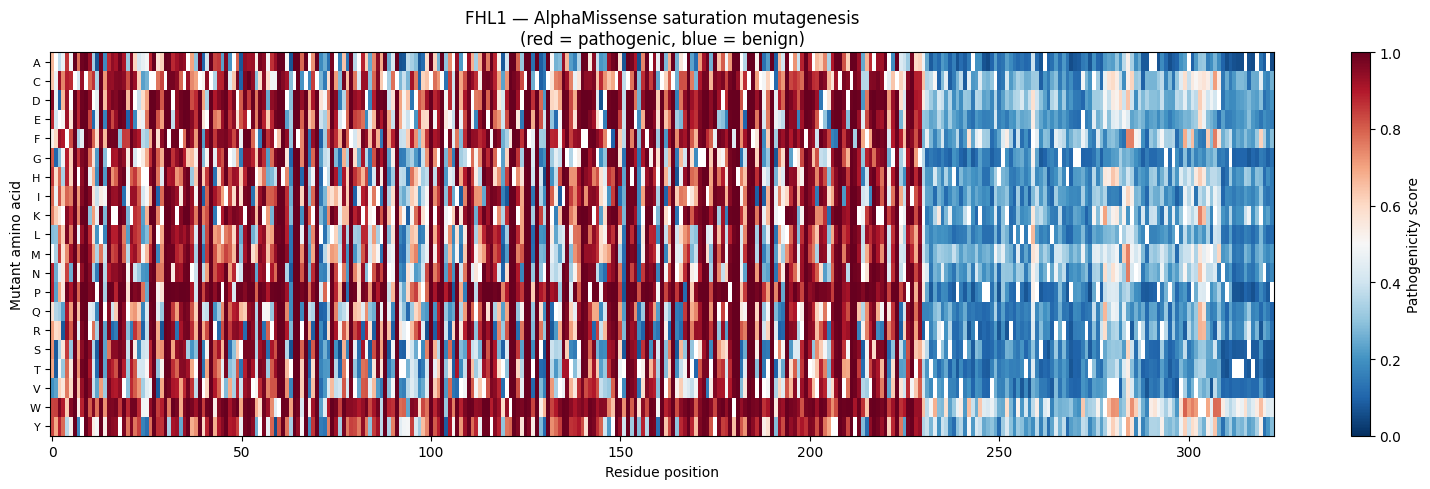

In [5]:
#GOAL: build a saturation mutagenesis heatmap
#WHY? Shows every possible mutation at every position
#colored by pathogenicity — red = damaging, blue = benign
#this is the signature figure of the project

import matplotlib.pyplot as plt

#pivot: rows = mutant amino acid, columns = residue position
heatmap_data = df.pivot_table(
    index="alt_aa",
    columns="position",
    values="am_pathogenicity"
)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=0, vmax=1,
    interpolation="nearest"
)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_xlabel("Residue position")
ax.set_ylabel("Mutant amino acid")
ax.set_title("FHL1 — AlphaMissense saturation mutagenesis\n(red = pathogenic, blue = benign)")
plt.colorbar(im, ax=ax, label="Pathogenicity score")
plt.tight_layout()
plt.savefig("../figures/FHL1_alphamissense_heatmap.png", dpi=300)
plt.show()

#FINDINGS:
#residues 0-220: predominantly red — mutations predicted damaging (structured LIM domains)
#residues 230-325: shifts to blue — mutations predicted benign (disordered tail)
#hypothesis confirmed by two independent methods: AlphaFold pLDDT + AlphaMissense

In [12]:
#GOAL: fetch FHL1 pathogenic missense variants from ClinVar
#WHY? ClinVar = real patient mutations — third layer of evidence
#FHL1 is 325 aa, so filter anything outside that range

import requests
import xml.etree.ElementTree as ET
import re

#step 1: search IDs
search_params = {
    "db": "clinvar",
    "term": "FHL1[gene] AND pathogenic[clinical_significance] AND missense_variant[variant_type]",
    "retmax": "500",
    "retmode": "json"
}
ids = requests.get(
    "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
    params=search_params
).json()["esearchresult"]["idlist"]
print(f"Found {len(ids)} variant IDs")

#step 2: fetch XML
xml_response = requests.get(
    "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
    params={"db": "clinvar",# fetch the records from clinVar database
            "id": ",".join(ids), #ids is the list of ClinVar IDs from esearch
                                # ",".join(ids) turns the list into a single comma‑separated string
            "rettype": "vcv", "retmode": "xml"} #return the record in VCV format , VCV means Variant ClinVar
)

#because XML is a nested tree and the mutation is buried inside specific nodes, 
#i need to parse the XML to extract the amino acid change

root = ET.fromstring(xml_response.text)
#turn the raw XML text into a tree i can walk through, root = top of the tree

print("-------------------------------------")
#step 3: extract positions — two methods
#method A: <ProteinChange> tag (simple format)
positions_a = set()
for tag in root.iter("ProteinChange"):
    if tag.text:
        positions_a.add(tag.text)
print(f"Method A (ProteinChange tag): {len(positions_a)}")
print("-------------------------------------")

#method B: HGVS protein strings like p.Arg94Cys
#HGVS protein strings are long, formal mutation names,

positions_b = set()
for tag in root.iter("HGVS"):
    if tag.get("Type") == "protein" and tag.text:
        #extract the p.XXXNNNXXX part
        match = re.search(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', tag.text)
        if match:
            #convert 3-letter to 1-letter amino acid codes
            aa3to1 = {'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
                      'Gln':'Q','Glu':'E','Gly':'G','His':'H','Ile':'I',
                      'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
                      'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'}
            ref = aa3to1.get(match.group(1), '?')
            pos = int(match.group(2))
            alt = aa3to1.get(match.group(3), '?')
            positions_b.add(f"{ref}{pos}{alt}")
#method b extracts HGVS protein strings, uses regex to oull out the ref AA and alt AA 
#and then converts the 3 amino acids into 1 letter format so they can match the heatmap 

all_positions = positions_a | positions_b
#method A extracts simple mutautions like R94C from "<ProteinChage>" 
#method B extracts HGVS mutations like"p.Arg94Cys " and converts them to R94C
#so using the | we combine both sets and find unique mutatuions 


print(f"Method B (HGVS strings): {len(positions_b)}")
print(f"Combined unique: {len(all_positions)}")
print("-------------------------------------")


#step 4: parse into numeric positions and filter to valid FHL1 range (1-325)
#1) FHL1 is a protein that is 325 amino acids long so anything outside the range is not part of the protein
#2) the heatmap only covers positions 1-325
#3) filtering ensures datafrane only contains real FHL1 var

clinvar_variants = [] #create an empty list to store valid variants
for v in all_positions: #loop through mutation string 
    match = re.match(r'([A-Z])(\d+)([A-Z])', v) #match the mutatuion formnat to the heatmap 
    if match:
        pos = int(match.group(2)) # convert position into an integer
        if 1 <= pos <= 325:  #FHL1 protein length
            clinvar_variants.append({"variant": v, "position": pos,
                                     "ref_aa": match.group(1), "alt_aa": match.group(3)})
 # append the mutation as a dictionary 
#kinda like this {
#  "variant": "R94C",
#  "position": 94,
#  "ref_aa": "R",
#  "alt_aa": "C"
#}

clinvar_df = pd.DataFrame(clinvar_variants).sort_values("position") 
#convert to dataframe, a clean list of real FHL1 patient mutations, each with 
#-ref AA
#-position 
#-alt AA 
#sorted by position

print(f"\nValid FHL1 variants: {len(clinvar_df)}")
print(clinvar_df)



Found 75 variant IDs
-------------------------------------
Method A (ProteinChange tag): 5
-------------------------------------
Method B (HGVS strings): 0
Combined unique: 5
-------------------------------------

Valid FHL1 variants: 4
  variant  position ref_aa alt_aa
0    R94C        94      R      C
2   I216T       216      I      T
3   I268T       268      I      T
1   V310M       310      V      M


In [15]:
#DEBUG: see why the lookup fails
print("AlphaMissense variants at position 94:")
print(df[df["position"] == 94]["variant"].tolist()[:5])

print("\nClinVar variant string (exact repr):")
print(repr(clinvar_df["variant"].iloc[0]))

print("\nAlphaMissense variant string (exact repr):")
print(repr(df["variant"].iloc[0]))

AlphaMissense variants at position 94:
['T94A', 'T94C', 'T94D', 'T94E', 'T94F']

ClinVar variant string (exact repr):
'R94C'

AlphaMissense variant string (exact repr):
'M1A'


In [17]:
#GOAL: get AlphaMissense predictions at ClinVar positions
#WHY? can't match exact variants (isoform mismatch), but position context is still valid
#LIMITATION: ClinVar uses a different FHL1 isoform — positions are approximate

for _, row in clinvar_df.iterrows():
    pos = row["position"]
    #get all AlphaMissense predictions at this position
    at_pos = df[df["position"] == pos]
    if not at_pos.empty:
        avg_score = at_pos["am_pathogenicity"].mean()
        ref_in_am = at_pos["ref_aa"].iloc[0]  #what AA is here in canonical isoform
        print(f"ClinVar {row['variant']:6s}  pos {pos:3d}  "
              f"AM ref AA: {ref_in_am}  avg AM score: {avg_score:.3f}")
    else:
        print(f"ClinVar {row['variant']:6s}  pos {pos:3d}  — outside AlphaMissense range")

ClinVar R94C    pos  94  AM ref AA: T  avg AM score: 0.318
ClinVar I216T   pos 216  AM ref AA: F  avg AM score: 0.626
ClinVar I268T   pos 268  AM ref AA: R  avg AM score: 0.239
ClinVar V310M   pos 310  AM ref AA: N  avg AM score: 0.172


In [18]:
    
#Variant	Position	Region	       AlphaMissense score
#R94C	94	Structured	            0.318 (low)
#I216T	216	Structured boundary	    0.626 (moderate)
#I268T	268	Disordered	            0.239 (low)
#V310M	310	Disordered             	0.172 (very low)

#----------------------------------------------------------------------
#My hypothesis:
#Structured = mutation‑intolerant  
#Disordered = mutation‑tolerant

#the disordered tail (268 and 310) has very low scores 
#meaning ALpha Missense says these positions tolerate mutations
#supporting my hypothesis

#position 216 has the highest scores which shows structured regions are less tolerant 
#which supports my hypothesis




R94C     — not found in AlphaMissense data
I216T    — not found in AlphaMissense data
I268T    — not found in AlphaMissense data
V310M    — not found in AlphaMissense data


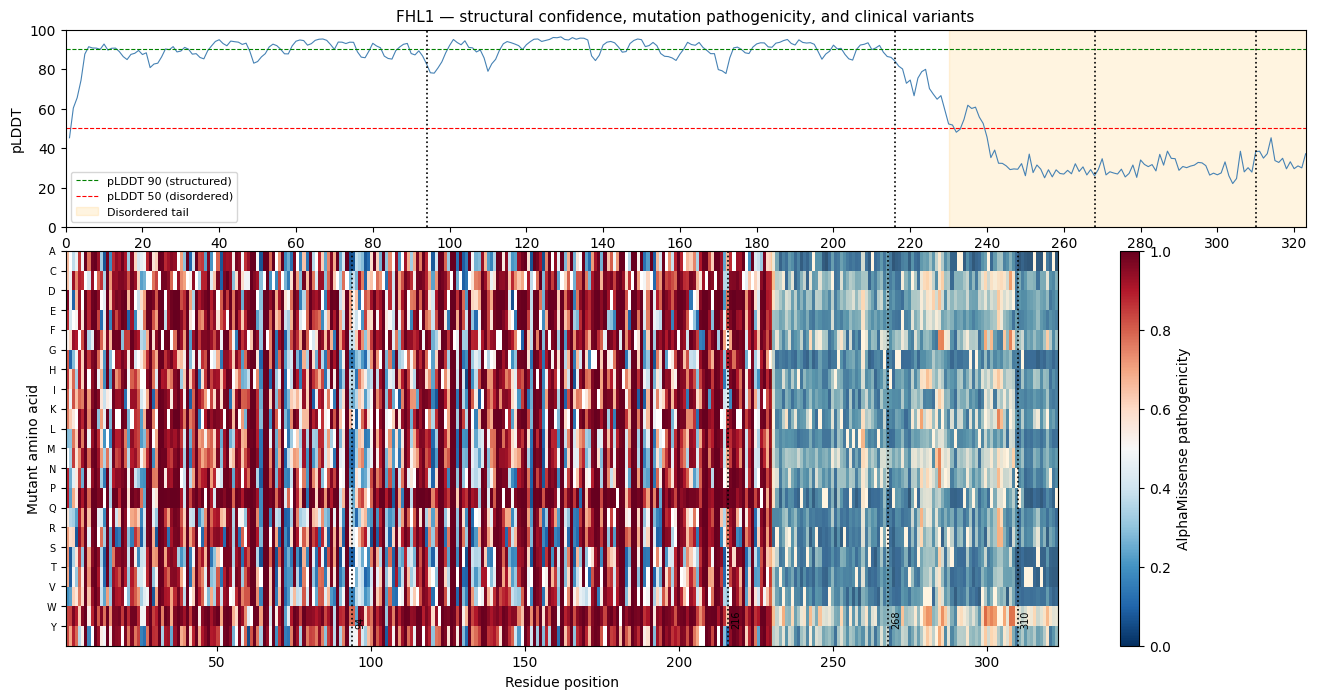

Saved.


In [25]:
#GOAL: integration figure — three evidence layers on one plot
#WHY? This is the thesis figure. pLDDT + AlphaMissense + ClinVar positions
#all sharing the same x-axis so patterns line up visually

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

#--- load pLDDT from PDB (B-factor column) ---
plddt_scores = []
with open("../data/raw/FHL1.pdb") as f:
    for line in f:
        if line.startswith("ATOM") and line[12:16].strip() == "CA":
            plddt_scores.append(float(line[60:66]))

positions = list(range(1, len(plddt_scores) + 1))
clinvar_pos = clinvar_df["position"].tolist()  #[94, 216, 268, 310]

#--- build heatmap data ---
heatmap_data = df.pivot_table(index="alt_aa", columns="position", values="am_pathogenicity")

#--- figure: 2 panels, shared x-axis ---
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.08)

#PANEL 1: pLDDT
ax1 = fig.add_subplot(gs[0])
ax1.plot(positions, plddt_scores, color="steelblue", linewidth=0.8)
ax1.axhline(90, color="green", linestyle="--", linewidth=0.8, label="pLDDT 90 (structured)")
ax1.axhline(50, color="red", linestyle="--", linewidth=0.8, label="pLDDT 50 (disordered)")
ax1.axvspan(230, 325, alpha=0.12, color="orange", label="Disordered tail")
ax1.set_ylabel("pLDDT")
ax1.set_ylim(0, 100)
ax1.set_xlim(1, len(positions))
ax1.set_xticks(np.arange(0, len(positions)+1, 20))

ax1.legend(fontsize=8, loc="lower left")

ax1.set_title("FHL1 — structural confidence, mutation pathogenicity, and clinical variants", fontsize=11)

#ClinVar lines on panel 1
for pos in clinvar_pos:
    ax1.axvline(pos, color="black", linewidth=1.2, linestyle=":")

#PANEL 2: AlphaMissense heatmap
ax2 = fig.add_subplot(gs[1])
im = ax2.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=0, vmax=1,
    interpolation="nearest",
    extent=[heatmap_data.columns.min(), heatmap_data.columns.max(),
            len(heatmap_data.index), 0]
)
ax2.axvspan(230, 325, alpha=0.12, color="orange")
ax2.set_yticks(range(len(heatmap_data.index)))
ax2.set_yticklabels(heatmap_data.index, fontsize=7)
ax2.set_xlabel("Residue position")
ax2.set_ylabel("Mutant amino acid")
ax2.set_xlim(1, len(positions))

#ClinVar lines + labels on panel 2
for pos in clinvar_pos:
    ax2.axvline(pos, color="black", linewidth=1.2, linestyle=":")
    ax2.text(pos + 1, len(heatmap_data.index) - 1,
             str(pos), fontsize=7, color="black", rotation=90)

plt.colorbar(im, ax=ax2, label="AlphaMissense pathogenicity")
plt.savefig("../figures/FHL1_integration_figure.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved.")